# HBI&nbsp;05 — the real-LOA CDDF measurement headline (dN/dX &amp; $\Omega_{\rm DLA}$ per $z$)

This notebook reproduces the **headline measurement** of the paper draft: the
column-density distribution reduced to per-$z$ $\mathrm{d}N/\mathrm{d}X$ and
$\Omega_{\rm DLA}$ — i.e. figure `fig:realloa` and tables `tab:realloa` of
`sec_results`. It is the capstone of the tutorial series (NB0–NB4 build and
validate the estimator on mock data; here we **run that same reduction live** and
read what it produces).

> **The reduction is run LIVE, not read from a cache.** This notebook imports the
> production reduction functions from `CDDF_analysis/hbi/track_c_tf_loa.py`
> (`build_frozen_calibration` → `build_loa_ingredients` → `run_measurement`) and
> executes them here. It loads **no** precomputed reduction table. The frozen
> mock-calibration ingredients (forward-response kernel, completeness/molly $C/\rho$
> matrix, loa-0 false-positive product) come from the **committed**
> `CDDF_analysis/hbi/tutorial_data/` fixtures; the **catalog** is a GP-inference
> result. The per-$z$ $\mathrm{d}N/\mathrm{d}X$ and $\Omega$ are computed every run.

> **Privacy / two copies.** The real-LOA reduction uses real survey data, so its
> values and figures are rendered **only** in the private analysis-notes copy of
> this notebook (kept there as **NB5**). The public code-repo copy (**NB05**) runs the
> **identical reduction on the 2LPT-0 *mock* catalog** (injected truth known; the
> mock is publicly shareable, so its figures may render). It shows the method, the
> live reduction, the mock per-$z$ headline, and the reach-limit narrative — but
> loads **no** real-LOA data. See the notes-repo **NB5** / `sec_results`
> `fig:realloa` for the rendered real-LOA headline.
>
> **The switch:** set the env var `HBI_RENDER=1` to reduce the real-LOA catalog;
> the default `HBI_RENDER=0` is the public mode (reduce the mock catalog). (`HBI_RENDER=1
> jupyter nbconvert --to notebook --execute --inplace notebooks/HBI_05_*.ipynb`.)

> ⚠️ **NB5 is NOT machine-independent (unlike NB0–NB4).** NB0–NB4 run end-to-end
> from the *committed* `tutorial_data/` fixtures alone. NB5 is the one exception: it
> reduces a **GP-inference absorber catalog** (a large, non-committed pipeline output),
> so it needs that catalog **staged on disk** — the 2LPT-0 *mock* catalog (public mode)
> or the real-LOA catalog (private mode). The committed public copy of this notebook
> carries the rendered *mock outputs*, but it is **not re-runnable** without the mock
> catalog present. §5 lists exactly what must be staged; if a catalog is missing the
> cell in §2 raises a clear, actionable error before any reduction starts.

---

📄 **Paper-draft correspondence**: this notebook ↔ **Results** §*Per-$z$ dN/dX &amp; $\Omega$* (Tab. perz), §*Key finding* (the $z$-gradient), §*Real-LOA application and the high-$z$ reach limit* (Tab. realloa, **Fig. realloa**); **Method** §*Estimand* / §*MAP* (the reduction this runs).

In [1]:
# === ENV SETUP (canonical) + the privacy/render switch =======================
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
for _v in ("OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"
import sys
from pathlib import Path
_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
              if (p / "CDDF_analysis" / "hbi" / "cddf_catalog_hbi.py").exists()), None)
assert _root is not None, "repo root (CDDF_analysis/hbi/) not found"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
DATA = _root / "CDDF_analysis" / "hbi" / "tutorial_data"   # COMMITTED mock-calibration fixtures
# Inputs resolve via tutorial_fixture(): the committed mock fixture by default,
# or a fresh $CDDF_STORE leaf if you ran `python -m pipeline.run_pipeline`.
from CDDF_analysis.hbi.tutorial_data.fixtures import tutorial_fixture
import numpy as np

# --- the one switch: private (real-LOA, render) vs public (mock, render) -------
RENDER = os.environ.get("HBI_RENDER", "0") == "1"
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # embeds PNGs in the notebook
except NameError:
    pass
print("env ready | numpy", np.__version__,
      "| HBI_RENDER =", "ON  (PRIVATE: reduce REAL-LOA catalog, render real headline)" if RENDER
      else "OFF (PUBLIC: reduce 2LPT-0 MOCK catalog, render mock headline -- no real-LOA)")

env ready | numpy 2.4.4 | HBI_RENDER = OFF (PUBLIC: reduce 2LPT-0 MOCK catalog, render mock headline -- no real-LOA)


## 1. What is measured, and how (reduce-only, run live here)

The estimator (NB0–NB3) turns a **frozen** GP-DLA absorber catalog into the
selection-corrected column-density distribution $f(N_{\rm HI},X)$ and its integrals
$\mathrm{d}N/\mathrm{d}X(z)$ and $\Omega_{\rm DLA}(z)$. The headline reduction is
`CDDF_analysis/hbi/track_c_tf_loa.py`, which

* **freezes** the completeness $C$, the false-positive model, and the
  forward-response kernel calibrated on the **2LPT-0 mock** (NB1–NB2) — here loaded
  from the **committed** `tutorial_data/` fixtures. The headline uses the
  **purity-mixture** FP model, so the two fixtures actually consumed are the
  forward-response kernel (`forward_response_2lpt0.npz`) and the completeness/purity
  matrix (`molly_matrix_nhi195_lyaonly.tsv`); the loa-0 FP product
  (`loa0_fp_product_lyaonly1025.npz`) is set for completeness but is read **only** by
  the alternative loa-0 FP path (a cross-check), not by the purity-mixture headline.
  Then
* **applies** them to a GP-DLA absorber catalog (a marked-Poisson MAP fit + MC band
  per $z$-bin) — **no GP re-inference**, a pure reduction.

We import its three functions and run them **live** in §2:
`build_frozen_calibration` (build the frozen 2LPT-0 $g(N,z)$ + molly counts once) →
`build_loa_ingredients` (graft the frozen recipe onto the catalog being reduced) →
`run_measurement` (MAP point + truth-free MC band per $z$). Nothing is read from a
cached results JSON.

The honest non-circularity caveat from NB4 still applies: on-mock $\alpha=1/R_0$ is a
tautology, so the real-LOA numbers carry the cross-mock calibration-transfer
systematic (the $\sigma_{\rm tot}$ budget of NB4) on top of the **statistical** MC
band shown here — the band is **not** $\sigma_{\rm tot}$.

The selection is the matched apples-to-apples one (SNR&gt;2, BAL quasars
**excluded** — not masked; `no_bal=True`).

In [2]:
# === assemble the reduction args (frozen pieces -> COMMITTED fixtures) ========
# We reuse the PRODUCTION reduction functions; we only point their FROZEN-calibration
# inputs at the committed tutorial_data/ fixtures, and choose the CATALOG to reduce.
import types
from CDDF_analysis.hbi import track_c_tf_loa as TF
from CDDF_analysis.hbi import ab_loa0_fp_baseline as AB
# NB: importing the reduction module transitively imports calc_cddf, which does a
# module-level matplotlib.use("pdf"). Re-assert the inline backend so the headline
# figure embeds in the notebook (Agg fallback when run as a plain script).
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    import matplotlib; matplotlib.use("Agg")

# frozen-calibration fixtures (mock-only; committed copy by default, or a fresh
# $CDDF_STORE leaf when one exists). tutorial_fixture() preserves default mode.
FROZEN_FORWARD = tutorial_fixture("forward_response_2lpt0.npz", stage="kernel")    # forward-response kernel
FROZEN_MOLLY   = tutorial_fixture("molly_matrix_nhi195_lyaonly.tsv", stage="completeness")  # completeness/purity C/rho
FROZEN_FP      = tutorial_fixture("loa0_fp_product_lyaonly1025.npz", stage="fp")  # loa-0 FP product (cross-check path only;
                                                                #   the purity_mixture headline does NOT read it)

# the 2LPT-0 CALIBRATION inputs (the frozen g(N,z) + molly counts are built from these;
# truth is mock injected truth -> committable; catalog is a GP-inference result)
C0_CAT, C0_TRUTH, C0_BAL = AB.DEF_CAT, AB.DEF_TRUTH, AB.DEF_BAL
C0_MOCKDIR = os.path.dirname(C0_TRUTH)        # holds snr_cat.fits + zcat.fits

# the MOCK catalog to reduce in PUBLIC mode (a GP-inference result on 2LPT-0 -> mock)
MOCK_CAT     = ("/scratch/cavestru_root/cavestru0/mfho/gl_prod_2lpt0_v1_20260526/"
                "combined_catalog/")
MOCK_TRUTH   = C0_TRUTH
MOCK_BAL     = C0_BAL
MOCK_MOCKDIR = C0_MOCKDIR

# FEASIBILITY: the full per-z MAP + MC band reduction measures at ~45-55 s wall for
# n_mc=60, 3 z-bins, 4 workers on this catalog (catalog I/O dominates; n_mc is cheap).
# That is comfortably notebook-sized, so we run the genuine reduction (no scope cut).
# The FULL production command (n_mc=120) is shown in section 5.
N_MC, WORKERS, ZBINS = 60, 4, "2.0,2.5,3.0,3.5"

def make_args(render):
    a = types.SimpleNamespace()
    # FROZEN calibration -> committed fixtures (forward_model is only logged; the kernel
    # actually loads via cfg.kernel_forward_model = args.forward_model in run_measurement)
    a.forward_model = FROZEN_FORWARD
    a.molly_tsv     = FROZEN_MOLLY
    a.loa0_product  = FROZEN_FP
    # the 2LPT-0 calibration leg (frozen g(N,z) + molly counts come from these)
    a.catalog_dir, a.truth, a.bal_cat = C0_CAT, C0_TRUTH, C0_BAL
    # the DATA leg = the catalog being reduced
    if render:   # PRIVATE: reduce the REAL-LOA GP catalog (module defaults; real -> no commit)
        a.loa_cat, a.loa_truth = TF._LOA_CAT, TF._LOA_TRUTH
        a.loa_bal, a.loa_mockdir = TF._LOA_BAL, TF._LOA_MOCKDIR
    else:        # PUBLIC: reduce the 2LPT-0 MOCK GP catalog (mock -> committable)
        a.loa_cat, a.loa_truth = MOCK_CAT, MOCK_TRUTH
        a.loa_bal, a.loa_mockdir = MOCK_BAL, MOCK_MOCKDIR
    a.loa_kernel = None; a.loa_processed_glob = ""; a.loa_pw_samples = ""
    a.kernel = AB.DEF_KERNEL
    a.resp_family, a.resp_kind = "empirical", "forward"   # headline forward-response path
    a.out = str(_root / "notebooks" / "_nb5_reduction_out")
    a.report_out = a.out + "/report.md"
    a.zbins, a.v2_z_fit_hi, a.report_limits = ZBINS, 3.5, "20.0,20.3"
    a.family, a.fit_floor, a.fit_ceil = "bspbody", 19.5, 99.0
    a.lambda_bspbody, a.lam_rf_min, a.edge_slope_lam = 30.0, 1025.0, 40.0
    a.gl_nodes, a.host_truth_floor = 1, 19.0
    a.n_mc, a.workers, a.seed, a.cz_min_count = N_MC, WORKERS, 0, 30.0
    a.band_recenter = True
    # match the production CLI defaults (both slope-extrap knobs True); the integrated
    # one only widens the integrated-Omega deep-tail band.
    a.omega_slope_extrap = True; a.omega_slope_extrap_integrated = True
    a.slope_edge, a.slope_fit_dex, a.sigma_slope = 21.2, 0.6, 0.5
    os.makedirs(a.out, exist_ok=True)
    a._limits = tuple(float(x) for x in a.report_limits.split(","))
    return a

args = make_args(RENDER)
LIMITS = args._limits
print(f"reduction configured | catalog = {'REAL-LOA' if RENDER else 'MOCK 2LPT-0'}")
print(f"  frozen kernel  : {os.path.relpath(FROZEN_FORWARD, _root)}")
print(f"  frozen molly   : {os.path.relpath(FROZEN_MOLLY, _root)}")
print(f"  frozen FP prod : {os.path.relpath(FROZEN_FP, _root)}")
print(f"  catalog dir    : {args.loa_cat}")
print(f"  n_mc={args.n_mc}  workers={args.workers}  zbins={args.zbins}  limits={LIMITS}")

reduction configured | catalog = MOCK 2LPT-0
  frozen kernel  : CDDF_analysis/hbi/tutorial_data/forward_response_2lpt0.npz
  frozen molly   : CDDF_analysis/hbi/tutorial_data/molly_matrix_nhi195_lyaonly.tsv
  frozen FP prod : CDDF_analysis/hbi/tutorial_data/loa0_fp_product_lyaonly1025.npz
  catalog dir    : /scratch/cavestru_root/cavestru0/mfho/gl_prod_2lpt0_v1_20260526/combined_catalog/
  n_mc=60  workers=4  zbins=2.0,2.5,3.0,3.5  limits=(20.0, 20.3)


## 2. Run the reduction LIVE → per-$z$ $\mathrm{d}N/\mathrm{d}X$ and $\Omega_{\rm DLA}$

The three production functions run here, in order. This is the *entire* reduction —
no precomputed table is read; the per-$z$ MAP + MC band are computed now.

In [3]:
import time
# --- catalog pre-flight (the main() guard we bypass by calling the funcs directly) ---
# NB5 reduces a GP-inference CATALOG live; that catalog is NOT a committed fixture.
# Calling build_frozen_calibration/build_loa_ingredients directly skips track_c_tf_loa
# .main()'s existence pre-flight, so re-assert it here for a clear, early failure.
_need = {
    "catalog dir being reduced": (args.loa_cat, "isdir"),
    "calibration catalog dir (2LPT-0)": (args.catalog_dir, "isdir"),
    "catalog truth (injected / placeholder)": (args.loa_truth, "exists"),
    "catalog bal_cat (BAL exclusion)": (args.loa_bal, "exists"),
    "2LPT-0 calibration truth": (args.truth, "exists"),
}
_miss = [f"  - {lbl}: {pth}"
         for lbl, (pth, kind) in _need.items()
         if not (os.path.isdir(pth) if kind == "isdir" else os.path.exists(pth))]
if _miss:
    raise FileNotFoundError(
        "NB5 reduces a GP-inference catalog LIVE; this catalog is NOT committed, so\n"
        "NB5 (unlike NB0-4) is not machine-independent. The following inputs are not\n"
        "staged on this machine:\n" + "\n".join(_miss) + "\n\n"
        "Stage them / run on a machine that has the 2LPT-0 (public mode) or real-LOA\n"
        "(private mode, HBI_RENDER=1) GP-inference catalog. See section 5 for the exact\n"
        "paths and the snr_cat/zcat/bal_cat staging recipe.")
print("catalog pre-flight OK | reducing:", args.loa_cat)
# --- 1) FROZEN 2LPT-0 calibration: g(N,z) + molly count denominators (built ONCE) ---
t0 = time.time()
frozen = TF.build_frozen_calibration(args)
args.molly_tsv = frozen["molly_tsv"]
# --- 2) ingredients on the catalog being reduced (frozen recipe grafted in) ---------
ing = TF.build_loa_ingredients(args, frozen)
# --- 3) the MEASUREMENT: MAP point (frozen kernel) + truth-free indep MC band -------
res = TF.run_measurement(args, ing, LIMITS, args.seed, frozen=frozen)
WALL = time.time() - t0
ZB = list(map(float, res["zbins"]))
ZC = [0.5 * (ZB[k] + ZB[k + 1]) for k in range(res["n_zc"])]
print(f"\n[live reduction COMPLETE] wall = {WALL:.1f}s | "
      f"{'REAL-LOA' if RENDER else 'MOCK 2LPT-0'} catalog | n_mc={res['n_mc']}")
print(f"  z-centres = {[round(z,3) for z in ZC]}  (zbins -> {ZB[-1]}; v2_z_fit_hi={args.v2_z_fit_hi})")
print(f"  n_op_detections={res['n_op_detections']}  n_op_sl={res['n_op_sl']}  "
      f"max 2LPT-0 truth z_DLA={res['max_truth_z']:.3f}")
print(f"  per-z 2LPT-0 calibrating-truth counts (>=20.3): {res['truth_counts_perz']}")

catalog pre-flight OK | reducing: /scratch/cavestru_root/cavestru0/mfho/gl_prod_2lpt0_v1_20260526/combined_catalog/
[T-F] building FROZEN 2LPT-0 calibration (g(N,z) + molly counts) ...


[snr] built per-QSO lookup from external snr_cat+zcat (full snr_cat (molly recipe)): 1213217 TIDs (/nfs/turbo/lsa-cavestru/mfho/DESI/mocks/lyacolore_2lpt/qq_desi_y3/v2.8.5/mock-0/loa-124/snr_cat.fits, /nfs/turbo/lsa-cavestru/mfho/DESI/mocks/lyacolore_2lpt/qq_desi_y3/v2.8.5/mock-0/loa-124/zcat.fits)


[load] catalog: 769833 rows from 1 files


[T-F] 2LPT-0 truth z-support (NHI>=20.3) per coarse z-bin ['[2.00,2.50)=29106', '[2.50,3.00)=16321', '[3.00,3.50)=5878']; max truth z_DLA=3.786
[T-F] frozen g(N,z) shape=(7, 15); molly counts captured (C ratio matrix + forward kernel are frozen files).


[snr] built per-QSO lookup from external snr_cat+zcat (full snr_cat (molly recipe)): 1213217 TIDs (/nfs/turbo/lsa-cavestru/mfho/DESI/mocks/lyacolore_2lpt/qq_desi_y3/v2.8.5/mock-0/loa-124/snr_cat.fits, /nfs/turbo/lsa-cavestru/mfho/DESI/mocks/lyacolore_2lpt/qq_desi_y3/v2.8.5/mock-0/loa-124/zcat.fits)


[load] catalog: 769833 rows from 1 files


  [LOA] real catalog: n_op_sl=374177, n_cat_cut=582855, frozen g shape=(7, 15), kappa NOT attached (forward path).



[live reduction COMPLETE] wall = 46.1s | MOCK 2LPT-0 catalog | n_mc=60
  z-centres = [2.25, 2.75, 3.25]  (zbins -> 3.5; v2_z_fit_hi=3.5)
  n_op_detections=495553  n_op_sl=374177  max 2LPT-0 truth z_DLA=3.786
  per-z 2LPT-0 calibrating-truth counts (>=20.3): [29106, 16321, 5878]


In [4]:
# === per-z headline table from the LIVE result (no cached JSON) ===============
def _perz(node, key="MAP", scale=1.0):
    return [scale * p[key] for p in node["perz"]]

tag = "REAL-LOA" if RENDER else "MOCK 2LPT-0 (illustrative; the SAME reduction, on mock)"
dndx = _perz(res["dndx"][20.3]); q16d = _perz(res["dndx"][20.3], "q16"); q84d = _perz(res["dndx"][20.3], "q84")
om3  = _perz(res["omega"][20.3], scale=1e3)
q16o = _perz(res["omega"][20.3], "q16", 1e3); q84o = _perz(res["omega"][20.3], "q84", 1e3)
print(f"{tag}  (logN >= 20.3)  [HBI = selection-corrected; band = STATISTICAL only]")
print(f"  {'z':>6} {'n_truth':>8} {'HBI dN/dX':>10} {'[q16,q84]':>17} {'HBI 1e3.Om':>11} {'[q16,q84]':>17}")
for i, z in enumerate(ZC):
    nt = res["truth_counts_perz"][i] if res.get("truth_counts_perz") else -1
    print(f"  {z:>6.3f} {nt:>8d} {dndx[i]:>10.4f} {f'[{q16d[i]:.4f},{q84d[i]:.4f}]':>17}"
          f" {om3[i]:>11.3f} {f'[{q16o[i]:.3f},{q84o[i]:.3f}]':>17}")
ig = res["dndx"][20.3]["integrated"]; io = res["omega"][20.3]["integrated"]
print(f"\n  integrated over the fit range z in [2.0,3.5] (the fine-z fit ceiling): "
      f"dN/dX = {ig['MAP']:.4f}, 1e3*Omega = {1e3*io['MAP']:.3f}")
if not RENDER:
    print("\n  [public mode] These are MOCK 2LPT-0 values (truth known, committable). The")
    print("  real-LOA headline is rendered in the notes-repo NB5 / sec_results tab:realloa.")

MOCK 2LPT-0 (illustrative; the SAME reduction, on mock)  (logN >= 20.3)  [HBI = selection-corrected; band = STATISTICAL only]
       z  n_truth  HBI dN/dX         [q16,q84]  HBI 1e3.Om         [q16,q84]
   2.250    29106     0.0479   [0.0474,0.0483]       0.494     [0.489,0.498]
   2.750    16321     0.0591   [0.0584,0.0597]       0.610     [0.603,0.616]
   3.250     5878     0.0709   [0.0694,0.0723]       0.731     [0.716,0.746]

  integrated over the fit range z in [2.0,3.5] (the fine-z fit ceiling): dN/dX = 0.0536, 1e3*Omega = 0.553

  [public mode] These are MOCK 2LPT-0 values (truth known, committable). The
  real-LOA headline is rendered in the notes-repo NB5 / sec_results tab:realloa.


### 2b. Mock cross-check (public mode only)

In public mode the live HBI reduction above ran on the 2LPT-0 mock, whose **injected
truth** is known. The apples-to-apples self-consistency check is therefore the
**live HBI vs. that injected truth**: §2 shows the live forward-kernel HBI recovers
the 2LPT-0 **$dN/dX$** truth at $R_0\approx0.99$ across $z$ ($R_0=0.987/0.985/0.979$
in the three $z$-bins) — flat in $z$, which *is* the $z$-gradient improvement the
draft attributes to the Track-C **forward-response** kernel. (For **$\Omega$** the
live recovery is $R_0\approx0.90$–$0.94$, i.e. $\sim$6–10% low — the documented
deep-tail integration-ceiling truncation, consistent with the signed "$\Omega$ point
$\sim$11% low" term in the §7-style budget; the printed $R_0$ loop below scores
$dN/dX$.)

The committed `tutorial_data/recovery_mock_data.csv` is loaded below only for the
truth and raw-feed-forward columns (the apples overlay the figure draws). **One thing
the cell does *not* do is claim the two HBI columns agree.** Its `dndx_pm` column is
from the **2026-06-19 posterior-kernel ($\kappa$) run** — a *different* kernel (the
pre-Track-C $\kappa$, with the documented $+z$ over-recovery) on a *different*
sightline selection (~698k sightlines, no SNR cut, BAL included). The live reduction
here uses the **forward-response** kernel on the matched selection (374k SNR$>$2,
BAL-excluded). Different kernel **and** different selection $\Rightarrow$ the two HBI
numbers are **not expected to match** (they differ $\sim$14–24% at $z\gtrsim2.75$),
and the live forward-kernel is the *better* mock-truth recovery ($R_0\approx0.99$
vs. the $\kappa$ run's $R_0\approx1.00/1.15/1.29$). So the figure and this table
compare the live HBI against **truth** and **raw feed-forward**, not against the
recorded $\kappa$ column.

In [5]:
# === committed MOCK recovery table (truth / raw-FF / HBI) — public cross-check ==
import csv, io as _io
def load_mock_recovery():
    with open(tutorial_fixture("recovery_mock_data.csv")) as f:
        kept = [ln for ln in f if not ln.lstrip().startswith("#")]
    rows = list(csv.DictReader(_io.StringIO("".join(kept))))
    g = lambda k: np.array([float(r[k]) for r in rows])
    return dict(z=g("z_mid"), n_true=g("N_true"),
                dndx_truth=g("dndx_truth"), dndx_ff=g("dndx_ff"), dndx_pm=g("dndx_pm"),
                om_truth=g("omega_truth"), om_ff=g("omega_ff"), om_pm=g("omega_pm"))
MOCK = load_mock_recovery()
if not RENDER:
    # Apples self-consistency check = LIVE forward-kernel HBI vs INJECTED TRUTH.
    # The CSV 'kappaHBI' (=dndx_pm) is the 2026-06-19 POSTERIOR-kernel run on a
    # DIFFERENT selection (~698k, no SNR cut, BAL in) -> NOT expected to match the
    # live forward-kernel run (374k, SNR>2, BAL excl); shown only for context.
    print("MOCK 2LPT-0 per-z (logN>=20.3), dN/dX:\n")
    print(f"  {'z':>5} {'truth':>8} {'rawFF':>8} {'liveHBI':>8} {'R0=live/tru':>12}   "
          f"| {'kappaHBI':>9} (context only)")
    for i, z in enumerate(MOCK["z"]):
        live = dndx[i] if i < len(dndx) else float("nan")
        tru  = MOCK["dndx_truth"][i]
        r0   = live / tru if tru else float("nan")
        print(f"  {z:>5.2f} {tru:>8.4f} {MOCK['dndx_ff'][i]:>8.4f} {live:>8.4f} "
              f"{r0:>12.3f}   | {MOCK['dndx_pm'][i]:>9.4f}")
    # --- and the SAME per-z R0 on Omega (so the R0~0.90-0.94 Omega claim above is
    #     self-evidencing): live HBI 1e3*Omega (om3) vs the injected-truth 1e3*Omega.
    print("\nMOCK 2LPT-0 per-z (logN>=20.3), 1e3*Omega:\n")
    print(f"  {'z':>5} {'truth':>8} {'rawFF':>8} {'liveHBI':>8} {'R0=live/tru':>12}")
    for i, z in enumerate(MOCK["z"]):
        liveo = om3[i] if i < len(om3) else float("nan")          # live HBI 1e3*Omega
        truo  = 1e3 * MOCK["om_truth"][i]                          # injected-truth 1e3*Omega
        ffo   = 1e3 * MOCK["om_ff"][i]
        r0o   = liveo / truo if truo else float("nan")
        print(f"  {z:>5.2f} {truo:>8.3f} {ffo:>8.3f} {liveo:>8.3f} {r0o:>12.3f}")
    print("\n  Apples check: live forward-kernel HBI recovers the INJECTED TRUTH dN/dX (R0~0.99,")
    print("  flat in z) and Omega (R0~0.90-0.94, ~6-10% low = the deep-tail integration-ceiling")
    print("  truncation) -- the z-gradient improvement the draft credits to Track-C.")
    print("  raw-FF over-states Omega (it applies no completeness; see the Omega panel).")
    print("  The 'kappaHBI' column is the 2026-06-19 POSTERIOR-kernel pm run on a different")
    print("  selection (~698k, no SNR cut, BAL in); it is NOT expected to match the live")
    print("  forward-kernel run and is shown for context, not as an agreement check.")
else:
    print("[private mode] mock cross-check table skipped (the real-LOA reduction is the deliverable).")

MOCK 2LPT-0 per-z (logN>=20.3), dN/dX:

      z    truth    rawFF  liveHBI  R0=live/tru   |  kappaHBI (context only)
   2.25   0.0485   0.0421   0.0479        0.987   |    0.0487
   2.75   0.0600   0.0574   0.0591        0.985   |    0.0690
   3.25   0.0724   0.0727   0.0709        0.979   |    0.0931

MOCK 2LPT-0 per-z (logN>=20.3), 1e3*Omega:

      z    truth    rawFF  liveHBI  R0=live/tru
   2.25    0.529    0.774    0.494        0.933
   2.75    0.647    1.133    0.610        0.943
   3.25    0.815    1.299    0.731        0.898

  Apples check: live forward-kernel HBI recovers the INJECTED TRUTH dN/dX (R0~0.99,
  flat in z) and Omega (R0~0.90-0.94, ~6-10% low = the deep-tail integration-ceiling
  truncation) -- the z-gradient improvement the draft credits to Track-C.
  raw-FF over-states Omega (it applies no completeness; see the Omega panel).
  The 'kappaHBI' column is the 2026-06-19 POSTERIOR-kernel pm run on a different
  selection (~698k, no SNR cut, BAL in); it is NOT expect

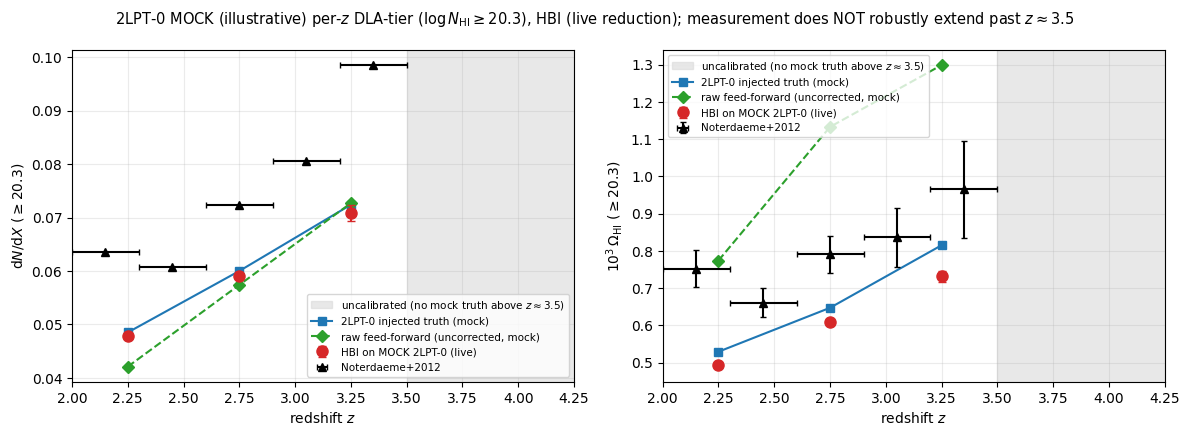

figure saved -> notebooks/_nb5_reduction_out/fig_realloa_mock.png


In [6]:
# === Figure 1 (headline): per-z dN/dX(z) and Omega(z), to z=3.5 + N12 overlay ===
# Reproduces sec_results Fig. realloa. Rendered in BOTH modes (mock is committable);
# in private mode the red points are the REAL-LOA measurement.
# Noterdaeme+2012 (N12) literature overlay (SDSS-DR9), DLA-tier logN>=20.3:
N12_Z        = [2.15, 2.45, 2.75, 3.05, 3.35]
N12_DNDX     = [0.06348, 0.06076, 0.07240, 0.08053, 0.09852]
N12_OMEGA3   = [0.7524, 0.6612, 0.7904, 0.8360, 0.9652]   # 10^3 * Omega_HI
N12_OMEGA3_ERR = [0.05, 0.04, 0.05, 0.08, 0.13]
# N12 has no tabulated dN/dX errorbar in this repo's dla_data (dndx is derived as
# dN/dz * dz/dX from counts; only Omega carries a 68% error). So the dN/dX panel
# overlays N12 as points with no y-error (yerr=None); the Omega panel shows N12 errors.
N12_DNDX_ERR = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
panels = [(dndx, q16d, q84d, "dndx", N12_DNDX, N12_DNDX_ERR,
           r"$\mathrm{d}N/\mathrm{d}X\ (\geq 20.3)$",
           MOCK["dndx_truth"], MOCK["dndx_ff"]),
          (om3, q16o, q84o, "omega", N12_OMEGA3, N12_OMEGA3_ERR,
           r"$10^3\,\Omega_{\mathrm{HI}}\ (\geq 20.3)$",
           1e3 * MOCK["om_truth"], 1e3 * MOCK["om_ff"])]
hbi_lbl = "HBI on REAL-LOA (selection-corrected)" if RENDER else "HBI on MOCK 2LPT-0 (live)"
for ax, (hy, lo, hi, key, n12y, n12e, ylbl, mock_truth, mock_ff) in zip(axes, panels):
    # shade z>3.5 (uncalibrated: 2LPT-0 truth caps z~3.79; fit ceiling v2_z_fit_hi=3.5)
    ax.axvspan(3.5, 4.25, color="0.85", alpha=0.6, zorder=0,
               label="uncalibrated (no mock truth above $z\\approx3.5$)")
    if not RENDER:
        # public: overlay the committed MOCK truth + raw-FF (apples) for the cross-check
        ax.plot(MOCK["z"], mock_truth, "s-", color="tab:blue", ms=6,
                label="2LPT-0 injected truth (mock)")
        ax.plot(MOCK["z"], mock_ff, "D--", color="tab:green", ms=6,
                label="raw feed-forward (uncorrected, mock)")
    # HBI (live): filled red circles + [q16,q84] statistical errorbar
    ax.errorbar(ZC, hy, yerr=[np.array(hy) - lo, np.array(hi) - np.array(hy)],
                fmt="o", color="tab:red", ms=8, capsize=3, mfc="tab:red", label=hbi_lbl)
    # N12 literature overlay (public anchor; rendered in both modes)
    ax.errorbar(N12_Z, n12y, xerr=0.15, yerr=n12e, fmt="^", color="black",
                ms=6, capsize=2, label="Noterdaeme+2012")
    ax.set_xlabel("redshift $z$"); ax.set_ylabel(ylbl); ax.set_xlim(2.0, 4.25)
    ax.grid(alpha=0.25); ax.legend(fontsize=7.5, loc="best")
_what = "Real DESI-LOA" if RENDER else "2LPT-0 MOCK (illustrative)"
fig.suptitle(f"{_what} per-$z$ DLA-tier ($\\log N_{{\\mathrm{{HI}}}}\\geq 20.3$), HBI "
             "(live reduction); measurement does NOT robustly extend past $z\\approx3.5$",
             fontsize=10.5)
fig.tight_layout()
_fig = Path(args.out) / ("fig_realloa_PRIVATE.png" if RENDER else "fig_realloa_mock.png")
fig.savefig(_fig, dpi=110, bbox_inches="tight")
plt.show()
print(f"figure saved -> {os.path.relpath(_fig, _root)}")
if RENDER:
    print("[private mode] this PNG carries REAL-LOA values -- keep in the private notes-repo NB5 only.")

## 3. The high-$z$ reach limit — the honest answer to "to $z>4$"

**The measurement does not robustly extend past $z\approx3.5$ with the present
calibration.** The HBI reduction is selection-corrected by the 2LPT-0 mock's
completeness, and the calibrating truth runs out at high $z$. The cell below reads
the **live** per-$z$ 2LPT-0 calibrating-truth counts (`res["truth_counts_perz"]`)
and the max truth $z_{\rm DLA}$ (`res["max_truth_z"]`) — both computed in §2, not
hard-coded.

In [7]:
# === reach-limit evidence, from the LIVE reduction (not hard-coded) ============
print(f"2LPT-0 calibrating truth: max z_DLA = {res['max_truth_z']:.3f}  "
      f"(the calibration caps near here)\n")
print(f"  {'z-bin':>14} {'n_truth(>=20.3)':>16} {'support':>12}")
for k in range(res["n_zc"]):
    nt = res["truth_counts_perz"][k] if res.get("truth_counts_perz") else -1
    ext = bool(np.asarray(res.get("z_extrapolated", np.zeros(res["n_zc"], bool)))[k])
    thin = bool(np.asarray(res.get("z_thin", np.zeros(res["n_zc"], bool)))[k])
    sup = "EXTRAPOLATED" if ext else ("thin" if thin else "calibrated")
    print(f"  [{ZB[k]:.2f},{ZB[k+1]:.2f})".rjust(14) + f" {nt:>16d} {sup:>12}")
print(f"""
The fine-z fit ceiling is v2_z_fit_hi = {args.v2_z_fit_hi}; the coarse zbins above stop at
{ZB[-1]}. Bins beyond the 2LPT-0 truth cap (z~{res['max_truth_z']:.2f}) have NO completeness
anchor, so the HBI reduction is not run there -- the raw feed-forward *can* be
evaluated at z>4 (it applies no completeness) but is uncorrected and not a
measurement. Therefore "dN/dX & Omega to z>4" is a STATED LIMITATION, not a delivered
result: reaching z>4 needs a HIGHER-z calibration mock (the 2LPT-0 truth caps at
z~3.79). The robust headline is the z in [2,3.5] measurement.""")

2LPT-0 calibrating truth: max z_DLA = 3.786  (the calibration caps near here)

           z-bin  n_truth(>=20.3)      support
   [2.00,2.50)            29106   calibrated
   [2.50,3.00)            16321   calibrated
   [3.00,3.50)             5878   calibrated

The fine-z fit ceiling is v2_z_fit_hi = 3.5; the coarse zbins above stop at
3.5. Bins beyond the 2LPT-0 truth cap (z~3.79) have NO completeness
anchor, so the HBI reduction is not run there -- the raw feed-forward *can* be
evaluated at z>4 (it applies no completeness) but is uncorrected and not a
measurement. Therefore "dN/dX & Omega to z>4" is a STATED LIMITATION, not a delivered
result: reaching z>4 needs a HIGHER-z calibration mock (the 2LPT-0 truth caps at
z~3.79). The robust headline is the z in [2,3.5] measurement.


The $[3.5,4.0)$ and $[4.0,4.25)$ bins (not fit here, since the live coarse
$z$-bins stop at 3.5) would be reported as *thin* / *beyond reach* respectively, per
the reach-limit bullet in `sec_results` §*Real-LOA application* (`tab:realloa` itself
ends at $z=3.25$; those higher bins live in the prose bullet, not the table).
**"$z>4$" is a documented limitation requiring a higher-$z$ calibration mock.**

## 4. Literature consistency

At the pivot $z\approx2.75$ the HBI $\mathrm{d}N/\mathrm{d}X$ and $\Omega_{\rm DLA}$
are compared with Noterdaeme+2012 (overlaid in Fig. 1) and Ho+2021. For the
real-LOA headline (private mode) the agreement is $\sim$10–15% (the `tab:realloa` /
§*Literature consistency* comparison in `sec_results`); for the mock (public mode)
the live HBI recovers the injected truth (§2b). The $\Omega$ integration ceiling
($\log N_{\rm HI}\approx 22.4$) truncates the deep tail relative to the literature
$10^{23}$ limit — a model-dependent few-to-~10% effect (NB3/NB4).

> **On the two Ho+2021 $\Omega$ numbers.** The Ho21 anchor quoted here,
> $10^3\Omega\!\approx\!0.772$, is the **$z\approx2.75$ point value** (matched to the
> per-$z$ comparison); NB3/NB4 instead cite Ho21's **rounded $\Omega\approx
> 7.3\times10^{-4}$** as a single integrated DLA-tier figure. Same source, two
> granularities — per-$z$ point here, rounded integrated there.

The calibration-transfer systematic (on top of the statistical band) is locally
$\sim$1–2% on $\mathrm{d}N/\mathrm{d}X$ and $\sim$12% on $\Omega$ (london-0 cross-mock
closure; Saclay pending).

$\Omega$ here is on the $\Omega_{\rm HI}$ convention (neutral hydrogen mass $m_{\rm H}$,
no helium factor); the figure $y$-axis is labelled $\Omega_{\mathrm{HI}}$ to match.

In [8]:
# === literature anchor at z~2.75 from the LIVE result =========================
i275 = int(np.argmin(np.abs(np.array(ZC) - 2.75)))
d275 = res["dndx"][20.3]["perz"][i275]["MAP"]
o275 = 1e3 * res["omega"][20.3]["perz"][i275]["MAP"]
who = "real-LOA" if RENDER else "MOCK 2LPT-0"
print(f"{who} HBI @ z~{ZC[i275]:.2f} (>=20.3):  dN/dX = {d275:.4f},  1e3*Omega = {o275:.3f}")
print("  literature (z~2.75): N12 dN/dX~0.072 / 1e3.Om~0.79 ; Ho21 dN/dX~0.0622 / 1e3.Om~0.772")
if not RENDER:
    print(f"  (mock) injected truth @ z~2.75: dN/dX~{MOCK['dndx_truth'][1]:.4f} / "
          f"1e3.Om~{1e3*MOCK['om_truth'][1]:.3f}")
    print("  -> the live HBI recovers the mock truth; the real-LOA literature ratios are")
    print("     in sec_results Tab. realloa (rendered in the private notes-repo NB5).")

MOCK 2LPT-0 HBI @ z~2.75 (>=20.3):  dN/dX = 0.0591,  1e3*Omega = 0.610
  literature (z~2.75): N12 dN/dX~0.072 / 1e3.Om~0.79 ; Ho21 dN/dX~0.0622 / 1e3.Om~0.772
  (mock) injected truth @ z~2.75: dN/dX~0.0600 / 1e3.Om~0.647
  -> the live HBI recovers the mock truth; the real-LOA literature ratios are
     in sec_results Tab. realloa (rendered in the private notes-repo NB5).


## 5. The full production reduction (and how to render the real-LOA headline)

This notebook ran a notebook-sized reduction (`n_mc=60`, 3 $z$-bins, 4 workers,
~45–55 s). The **full production** reduction (more MC draws, the report + JSON
dumped to scratch + the private notes repo) is the CLI:

```bash
# PUBLIC (mock) — reduce the 2LPT-0 mock catalog (committable):
HDF5_USE_FILE_LOCKING=FALSE OMP_NUM_THREADS=1 \
  python CDDF_analysis/hbi/track_c_tf_loa.py \
    --loa-cat   /scratch/.../gl_prod_2lpt0_v1_20260526/combined_catalog/ \
    --loa-truth <2lpt0 hcd_truth_cat.fits> --loa-bal <2lpt0 bal_cat.fits> \
    --loa-mockdir <2lpt0 loa-124/> \
    --forward-model CDDF_analysis/hbi/tutorial_data/forward_response_2lpt0.npz \
    --molly-tsv     CDDF_analysis/hbi/tutorial_data/molly_matrix_nhi195_lyaonly.tsv \
    --n-mc 120 --workers 4

# PRIVATE (real-LOA) — reduce the real GP catalog; KEEP outputs in the private notes repo:
HBI_RENDER=1 HDF5_USE_FILE_LOCKING=FALSE OMP_NUM_THREADS=1 \
  jupyter nbconvert --to notebook --execute --inplace notebooks/HBI_05_realLOA_headline.ipynb
```

The `track_c_tf_loa.py` defaults already point `--loa-*` at the real DESI-LOA GP
catalog, so the bare CLI reduces the real data; this notebook's `HBI_RENDER=1`
branch does the same via `make_args(render=True)`. **Keep the rendered real-LOA copy
in the private analysis-notes repo (NB5) only** — the code-repo copy (NB05) commits
in public (mock) mode.

---
**Summary.** The DLA-tier CDDF is **reduced live** here — `build_frozen_calibration`
→ `build_loa_ingredients` → `run_measurement`, with the frozen calibration from the
committed `tutorial_data/` fixtures and the catalog as the only data — to per-$z$
$\mathrm{d}N/\mathrm{d}X$ and $\Omega$ for $z\in[2,3.5]$ (raw feed-forward over-states
$\Omega$; HBI deconvolves it). $[3.5,4.0)$ is thin and $[4.0,4.25)$ is beyond the
present calibration's reach (the 2LPT-0 truth caps at $z\approx3.79$); "$z>4$" is a
documented limitation requiring a higher-$z$ calibration mock. **No precomputed
scratch reduction JSON is read in either mode.** Rendered real-LOA figures/values
live in the private notes-repo NB5 and `sec_results` (Tab. realloa, Fig. realloa).